### Defining the portfolio

In [ ]:
tickers = ["RELIANCE.NS", "HDFCBANK.NS"]
units = [10, 10]

portfolio_df = pd.DataFrame({'Stocks': tickers,
                          'units': units})

In [ ]:
portfolio_df

,Stocks,units
0,RELIANCE.NS,10
1,HDFCBANK.NS,10


### Defining the time period

In [ ]:
start_date = date(2022, 1, 1)
end_date = date.today()

### Collecting the data and storing it as a parquet file

In [ ]:
data = yf.download(tickers + ["^NSEI"], start = start_date, end = end_date, group_by = "ticker")

[*********************100%***********************]  3 of 3 completed


In [ ]:
data.head()

Ticker             ^NSEI                                                      \
Price               Open          High           Low         Close    Volume   
Date                                                                           
2022-01-03  17387.150391  17646.650391  17383.300781  17625.699219  200500.0   
2022-01-04  17681.400391  17827.599609  17593.550781  17805.250000  247400.0   
2022-01-05  17820.099609  17944.699219  17748.849609  17925.250000  251500.0   
2022-01-06  17768.500000  17797.949219  17655.550781  17745.900391  236500.0   
2022-01-07  17797.599609  17905.000000  17704.550781  17812.699219  239300.0   

Ticker     HDFCBANK.NS                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2022-01-03  706.321700  724.395925  704.181331  722.802551   9069184   
2022-01-04  722.968982  729.104717  717.166228  727.035706   8857352   
2022-01-05  730.959734  747.702150  726.821652  744.301331  14332638   
2022-01-06  733.908615  739.497355  727.749133  732.362793   9628930   
2022-01-07  734.384368  745.205122  730.531715  737.499817  11179384   

Ticker      RELIANCE.NS                                                   
Price              Open         High          Low        Close    Volume  
Date                                                                      
2022-01-03  1076.103491  1095.646251  1075.443709  1093.780640   5421611  
2022-01-04  1099.263532  1119.784530  1093.848795  1118.464966  10847728  
2022-01-05  1120.239614  1127.064782  1107.021470  1123.697632  11643813  
2022-01-06  1115.325533  1116.599603  1096.123977  1099.536621  14447422  
2022-01-07  1106.111499  1118.442271  1097.284238  1108.409302  13112115

In [ ]:
data.shape

(1033, 15)

In [ ]:
data_df = (data.stack(level = 0).rename_axis(["date", "ticker"]).reset_index())  # moving tickers to rows
data_df.columns = [c.lower() for c in data_df.columns]

print(data_df.head())

        date       ticker          open          high           low  \
0 2022-01-03        ^NSEI  17387.150391  17646.650391  17383.300781   
1 2022-01-03  HDFCBANK.NS    706.321700    724.395925    704.181331   
2 2022-01-03  RELIANCE.NS   1076.103491   1095.646251   1075.443709   
3 2022-01-04        ^NSEI  17681.400391  17827.599609  17593.550781   
4 2022-01-04  HDFCBANK.NS    722.968982    729.104717    717.166228   

          close     volume  
0  17625.699219   200500.0  
1    722.802551  9069184.0  
2   1093.780640  5421611.0  
3  17805.250000   247400.0  
4    727.035706  8857352.0  


In [ ]:
data_df = data_df.sort_values(["ticker", "date"])
data_df = data_df.dropna(subset = ["close"])

data_df["date"] = pd.to_datetime(data_df["date"])
data_df["year"] = data_df["date"].dt.year

In [ ]:
data_df.dtypes

date      datetime64[s]
ticker              str
open            float64
high            float64
low             float64
close           float64
volume          float64
year              int32
dtype: object

In [ ]:
os.makedirs("data/prices", exist_ok = True)

for year, group in data_df.groupby(data_df["date"].dt.year):
    group.to_parquet(f"data/prices/prices_{year}.parquet",
                     engine = "pyarrow",
                     compression = "snappy",
                     index = False)

### Variance Covriance Matrix

In [ ]:
portfolio_files = glob.glob("data/prices/*.parquet")
portfolio_files

['data/prices/prices_2025.parquet',
 'data/prices/prices_2024.parquet',
 'data/prices/prices_2026.parquet',
 'data/prices/prices_2022.parquet',
 'data/prices/prices_2023.parquet']

In [ ]:
df = pd.concat([pd.read_parquet(file) for file in portfolio_files], ignore_index = True)

In [ ]:
# Sorting by ticker and date
df = df.sort_values(['ticker', 'date'])

# Calculating percentage returns
df['return'] = df.groupby('ticker')['close'].pct_change()

In [ ]:
print('Length of the dataset:', len(df))
df = df.dropna(subset = ['return'])

print('Length of dataset after dropping NaN values', len(df))

Length of the dataset: 3098
Length of dataset after dropping NaN values 3095


In [ ]:
returns = df.pivot(index = 'date', columns = 'ticker', values = 'return')
returns

ticker,HDFCBANK.NS,RELIANCE.NS,^NSEI
date,,,
2022-01-04,0.005857,0.022568,0.010187
2022-01-05,0.023748,0.004678,0.006740
2022-01-06,-0.016040,-0.021501,-0.010005
2022-01-07,0.007014,0.008069,0.003764
2022-01-10,0.005546,0.000821,0.010700
...,...,...,...
2026-02-27,-0.012074,-0.009170,-0.012468
2026-03-02,-0.009406,-0.025755,-0.012429
2026-03-04,-0.012224,-0.009573,-0.015491


In [ ]:
# compute variance‑covariance matrix from the returns DataFrame
cov_matrix = returns.cov()
cov_matrix

ticker,HDFCBANK.NS,RELIANCE.NS,^NSEI
ticker,,,
HDFCBANK.NS,0.000164,0.000064,0.000074
RELIANCE.NS,0.000064,0.000192,0.000083
^NSEI,0.000074,0.000083,0.000072


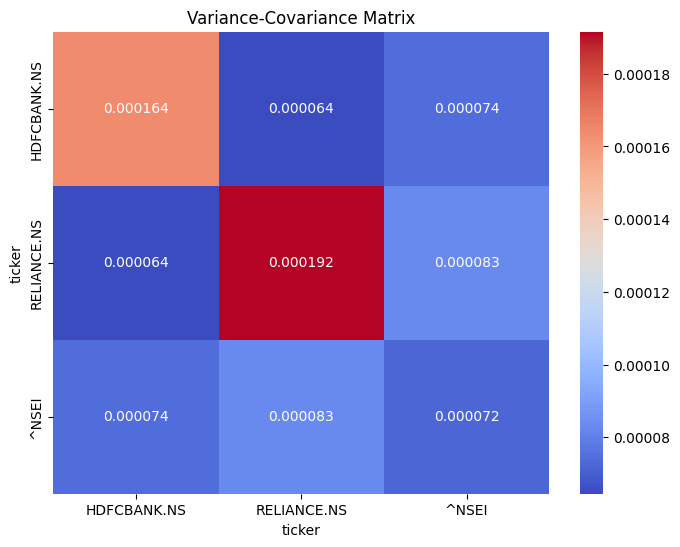

In [ ]:
plt.figure(figsize = (8, 6))
sns.heatmap(cov_matrix, annot = True, cmap = 'coolwarm', fmt = '.6f')
plt.title('Variance-Covariance Matrix')
plt.show()